## import libraries and data

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
from src.extraction import load_processed, FEATURE_COLUMNS, save_model, load_model
from src.classification import build_X_y, split_data, analyze_imbalance, train_model,evaluate_models, plot_all_confusion_matrices, plot_f1_comparison, cross_validate_models, plot_cv_boxplot, tune_models, select_best_model, get_feature_importance, plot_feature_importance
from sklearn.metrics import classification_report

df_clean_clusters = load_processed("df_clean_with_target.csv")
df_clean_clusters = df_clean_clusters[FEATURE_COLUMNS + ["target"]]

df_clean_clusters

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,target
0,40.900749,95.40,0.00,95.40,0.000000,1000.0,201.802084,Clients à Faible Activité
1,3202.467416,0.00,0.00,0.00,6442.945483,7000.0,4103.032597,Clients à Risque
2,2495.148862,773.17,773.17,0.00,0.000000,7500.0,622.066742,Clients Premium
3,1666.670542,1499.00,1499.00,0.00,205.788017,7500.0,0.000000,Clients à Faible Activité
4,817.714335,16.00,16.00,0.00,0.000000,1200.0,678.334763,Clients à Faible Activité
...,...,...,...,...,...,...,...,...
8944,28.493517,291.12,0.00,291.12,0.000000,1000.0,325.594462,Clients à Faible Activité
8945,19.183215,300.00,0.00,300.00,0.000000,1000.0,275.861322,Clients à Faible Activité
8946,23.398673,144.40,0.00,144.40,0.000000,1000.0,81.270775,Clients à Faible Activité
8947,13.457564,0.00,0.00,0.00,36.558778,500.0,52.549959,Clients à Faible Activité


## Build X / y and stratified train/test split

In [2]:
X, y = build_X_y(df_clean_clusters)

X_train, X_test, y_train, y_test = split_data(X, y)

# check if the Stratification have the same proportions
display(pd.DataFrame({
    "train" : y_train.value_counts(normalize=True),
    "test"  : y_test.value_counts(normalize=True)
}))

,train,test
target,,
Clients Premium,0.399078,0.398883
Clients à Faible Activité,0.333706,0.334078
Clients à Risque,0.267216,0.267039


## Class imbalance analysis

In [3]:
table, ratio, needs_resampling = analyze_imbalance(y_train)
display(table)
print(f"Imbalance ratio (largest / smallest): {ratio}")
print("Resampling needed:", needs_resampling)

SAMPLING = "over" if needs_resampling else "none"
print("Sampling strategy used in the pipeline:", SAMPLING)

,count,pct
target,,
Clients Premium,2857,39.9
Clients à Faible Activité,2389,33.4
Clients à Risque,1913,26.7


Imbalance ratio (largest / smallest): 1.49
Resampling needed: False
Sampling strategy used in the pipeline: none


## Training the 4 pipelines

In [4]:
pipelines, train_times = train_model(X_train, y_train, sampling=SAMPLING)

display(train_times)

for name, pipeline in pipelines.items():
    print(f"{name} test accuracy = {pipeline.score(X_test, y_test):.3f}")

pipelines["svm"]

,train_time_s
model,
random_forest,0.509
svm,2.540
decision_tree,0.037
logistic_regression,0.125


random_forest test accuracy = 0.970
svm test accuracy = 0.911
decision_tree test accuracy = 0.946
logistic_regression test accuracy = 0.906


,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[object](3,)","['Clients Premium','Clients à Faible Activité','Clients à Risque']"
feature_names_in_,"ndarray[object](7,)","['BALANCE','PURCHASES','ONEOFF_PURCHASES',...,'CASH_ADVANCE', 'CREDIT_LIMIT','PAYMENTS']"
n_features_in_,int,7
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## Evaluation on the test set,

In [5]:
comparison = evaluate_models(pipelines, X_test, y_test, train_times)
display(comparison)

for name, pipeline in pipelines.items():
    print(f"===== {name} =====")
    print(classification_report(y_test, pipeline.predict(X_test), digits=3))

,accuracy,precision_macro,recall_macro,f1_macro,train_time_s
model,,,,,
random_forest,0.9698,0.9707,0.9697,0.9702,0.509
decision_tree,0.9458,0.9458,0.9474,0.9466,0.037
svm,0.9106,0.9077,0.9156,0.9106,2.540
logistic_regression,0.9056,0.9035,0.9090,0.9058,0.125


===== random_forest =====
                           precision    recall  f1-score   support

          Clients Premium      0.968     0.975     0.971       714
Clients à Faible Activité      0.963     0.962     0.962       598
         Clients à Risque      0.981     0.973     0.977       478

                 accuracy                          0.970      1790
                macro avg      0.971     0.970     0.970      1790
             weighted avg      0.970     0.970     0.970      1790

===== svm =====
                           precision    recall  f1-score   support

          Clients Premium      0.952     0.881     0.915       714
Clients à Faible Activité      0.898     0.910     0.904       598
         Clients à Risque      0.874     0.956     0.913       478

                 accuracy                          0.911      1790
                macro avg      0.908     0.916     0.911      1790
             weighted avg      0.913     0.911     0.911      1790

===== decision

In [6]:
##

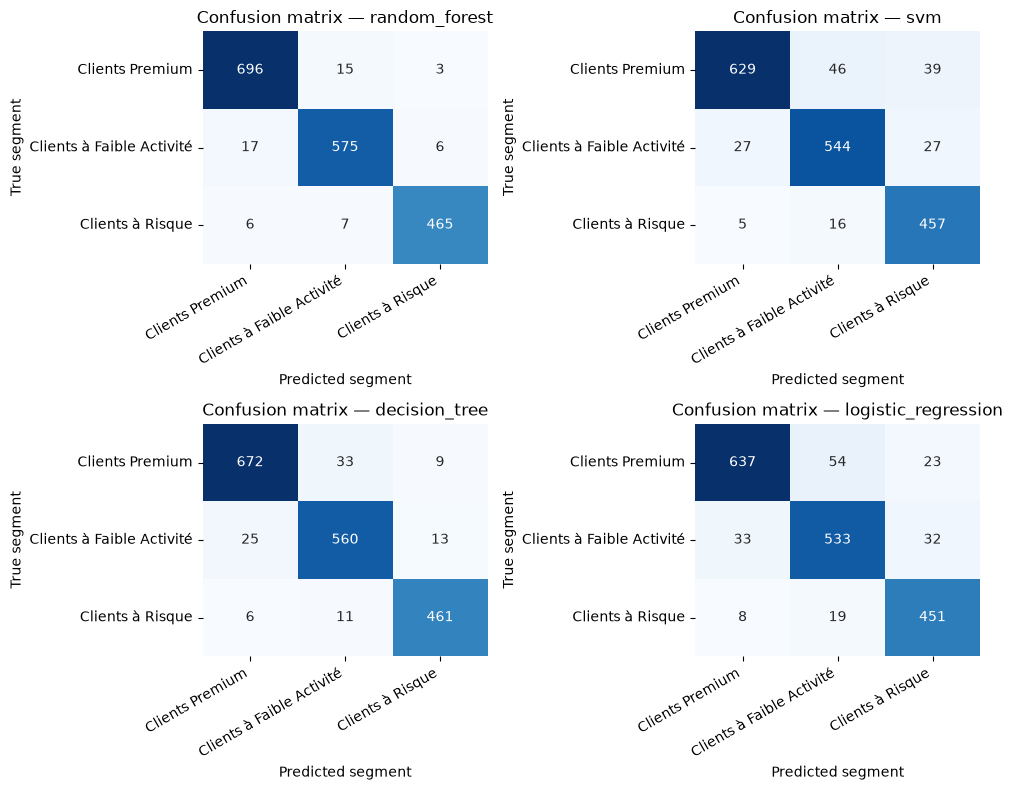

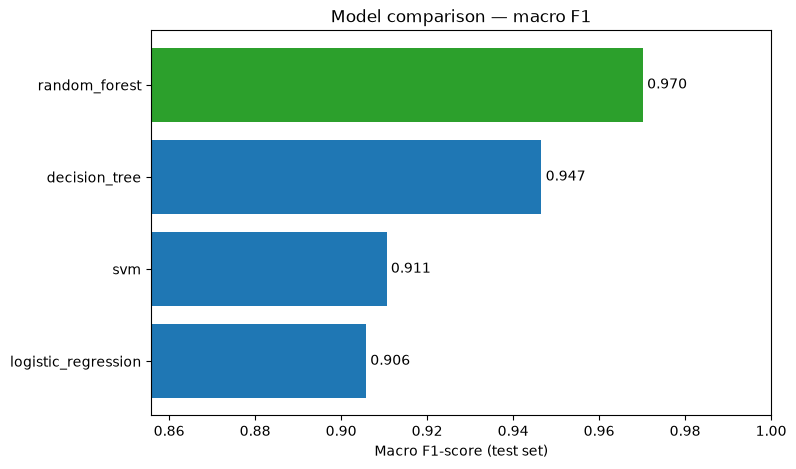

In [7]:
plot_all_confusion_matrices(pipelines, X_test, y_test)
plt.show()

plot_f1_comparison(comparison)
plt.show()

## Cross-validation (stability)

,mean,std,min,max
model,,,,
random_forest,0.9687,0.0042,0.9640,0.9754
decision_tree,0.9473,0.0056,0.9407,0.9549
svm,0.9084,0.0076,0.8983,0.9181
logistic_regression,0.9054,0.0052,0.9000,0.9128


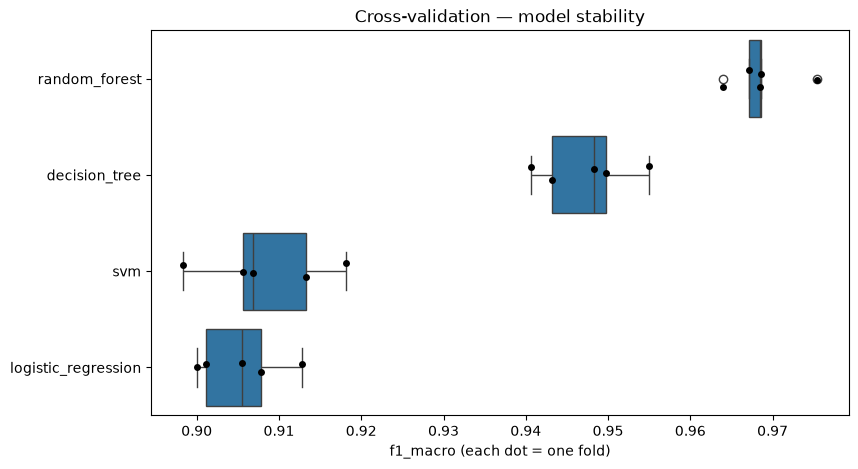

In [8]:
cv_scores = cross_validate_models(X_train, y_train, sampling=SAMPLING)

summary = (cv_scores.groupby("model")["f1_macro"]
           .agg(["mean", "std", "min", "max"])
           .sort_values("mean", ascending=False).round(4))
display(summary)

plot_cv_boxplot(cv_scores)
plt.show()

## Hyperparameter tuning

In [9]:
tuned_pipelines, tuning_summary = tune_models(X_train, y_train, sampling=SAMPLING, search="random", n_iter=20)
display(tuning_summary)

tuned_comparison = evaluate_models(
    tuned_pipelines, X_test, y_test,
    train_times=tuning_summary[["search_time_s"]],
)
display(tuned_comparison)

,best_cv_f1_macro,best_params,search_time_s
model,,,
random_forest,0.9692,"{'classifier__n_estimators': 400, 'classifier_...",69.1
decision_tree,0.9473,"{'classifier__min_samples_leaf': 1, 'classifie...",0.9
svm,0.9422,"{'classifier__estimator__gamma': 'scale', 'cla...",36.4
logistic_regression,0.9113,{'classifier__C': 100},0.3


,accuracy,precision_macro,recall_macro,f1_macro,search_time_s
model,,,,,
random_forest,0.9693,0.9701,0.9692,0.9696,69.1
decision_tree,0.9458,0.9458,0.9474,0.9466,0.9
svm,0.9430,0.9429,0.9459,0.9443,36.4
logistic_regression,0.9134,0.9121,0.9172,0.9143,0.3


## Best model, feature importance, saving,

Best model: random_forest
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 RandomForestClassifier(n_estimators=400, n_jobs=-1,
                                        random_state=42))])


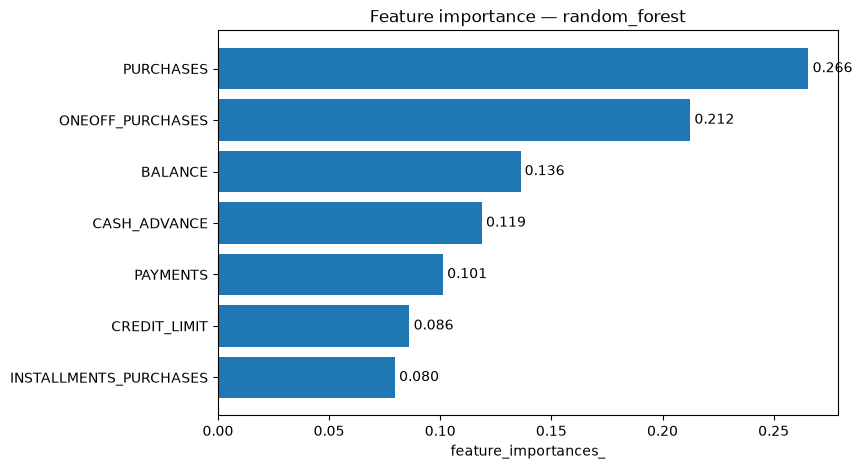

Saved to: /home/ouelaimar/Desktop/CardProfiler/models/best_pipeline.joblib


In [10]:
best_name, best_pipeline = select_best_model(tuned_comparison, tuned_pipelines)
print("Best model:", best_name)
print(best_pipeline)

importance = get_feature_importance(best_pipeline, X_test, y_test)
plot_feature_importance(importance, best_name)
plt.show()

path =  save_model(best_pipeline, "best_pipeline.joblib")
print("Saved to:", path)


## MLflow tracking

In [11]:
from src.tracking import setup_mlflow, log_runs

setup_mlflow()

runs = log_runs(
    tuned_pipelines, X_test, y_test, best_params=tuning_summary["best_params"].to_dict(),extra_params={"sampling": SAMPLING, "search": "grid"},
)

display(runs.sort_values("f1_macro", ascending=False))

2026/10/08 17:13:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/08 17:13:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/10/08 17:13:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mec

,run_id,model_uri,accuracy,precision_macro,recall_macro,f1_macro
model,,,,,,
random_forest,bc280504f4da42089802e275039ea0ab,models:/m-8b007e54628341f993dcac6b2e1109f8,0.9693,0.9701,0.9692,0.9696
decision_tree,bb403cebe27d4b2d90b3cf085d39f76c,models:/m-3e99517fedc94a6eadb5bf4af1e9843a,0.9458,0.9458,0.9474,0.9466
svm,758c1c6b176e437082afa9f96a2a4baa,models:/m-2bdbfba478554d138b07185ef77d6b1c,0.9430,0.9429,0.9459,0.9443
logistic_regression,4b74de8c927f4327b386531f484c7433,models:/m-53ffd3d76f584e0582bd6b9802202d2b,0.9134,0.9121,0.9172,0.9143


## Reload a logged model

In [12]:
import mlflow

best_uri = runs.sort_values("f1_macro", ascending=False)["model_uri"].iloc[0]
reloaded = mlflow.sklearn.load_model(best_uri)

print("Reloaded:", best_uri)
print(reloaded.predict(X_test.head()))

Reloaded: models:/m-8b007e54628341f993dcac6b2e1109f8
['Clients Premium' 'Clients Premium' 'Clients à Risque'
 'Clients à Faible Activité' 'Clients à Faible Activité']
